## Data integration and pre-processing for datasets

### Loading the dataset

In [1]:
#Author: Petter Rignell

import yfinance as yf
import pandas as pd

index_data = yf.download('^GSPC', start='1960-4-20', end='2025-04-21')

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


### Price data and technical indicators

In [2]:
from ta.momentum import RSIIndicator, StochasticOscillator, ROCIndicator
from ta.trend import MACD, SMAIndicator, ADXIndicator, IchimokuIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

close = index_data['Close'].squeeze()
high = index_data['High'].squeeze()
low = index_data['Low'].squeeze()
volume = index_data['Volume'].squeeze()

#ChatGPT helped organizing each of the feature/technical indicator I specified

# Momentum indicators
index_data['RSI'] = RSIIndicator(close=close, window=14).rsi()
index_data['Stoch_Oscillator'] = StochasticOscillator(high=high, low=low, close=close).stoch()
index_data['ROC_indi'] = ROCIndicator(close=close).roc()

# Trend indicators
index_data['MACD'] = MACD(close=close).macd()
index_data['ADX_indi'] = ADXIndicator(high=high, low=low, close=close).adx()
ichi = IchimokuIndicator(high=high, low=low)
index_data['ichimoku_conversion'] = ichi.ichimoku_conversion_line()
index_data['ichimoku_base'] = ichi.ichimoku_base_line()
index_data['ichimoku_a'] = ichi.ichimoku_a()
index_data['ichimoku_b'] = ichi.ichimoku_b()
index_data['SMA_20'] = SMAIndicator(close=close, window=20).sma_indicator()
index_data['SMA_50'] = SMAIndicator(close=close, window=50).sma_indicator()
index_data['SMA_200'] = SMAIndicator(close=close, window=200).sma_indicator()

# Volatility indicators
index_data['Bollinger_HBand'] = BollingerBands(close=close).bollinger_hband()
index_data['ATR'] = AverageTrueRange(high=high, low=low, close=close).average_true_range()

# Volume indicators
index_data['OBVI'] = OnBalanceVolumeIndicator(close=close, volume=volume).on_balance_volume()
index_data.columns = index_data.columns.droplevel(1)

#from 4/20/1982, no price feature had nan values, hence no interpolation and ffill needed for price, volume, and technical indicators
index_data = index_data.loc['4/20/1982 00:00:00':]
print(index_data.shape)
print(index_data.isna().sum())

index_data.head()

ValueError: negative dimensions are not allowed

### Technical Indicator Correlation for dataset 1

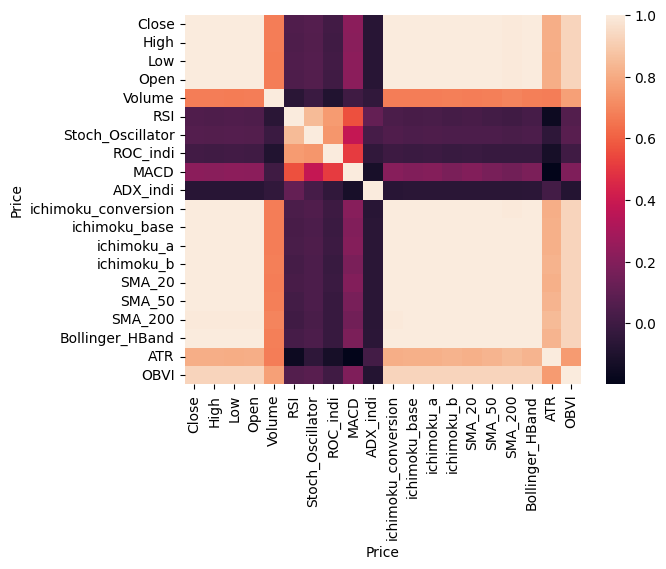

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = index_data.corr()

sns.heatmap(corr)
plt.show()

### Technical Indicator Feature Importance for dataset 1

In [ ]:
from sklearn.ensemble import RandomForestRegressor

#Random forest regressor for feature importance. Format from ChatGPT
#but modified for this particular purpose, targeting close price

X = index_data.drop('Close', axis=1)
y = index_data['Close']

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance)

                Feature  Importance
0                  High    0.658524
1                   Low    0.248197
2                  Open    0.060815
3                Volume    0.000002
4                   RSI    0.000003
5      Stoch_Oscillator    0.000006
6              ROC_indi    0.000002
7                  MACD    0.000001
8              ADX_indi    0.000002
9   ichimoku_conversion    0.015532
10        ichimoku_base    0.000572
11           ichimoku_a    0.002242
12           ichimoku_b    0.000995
13               SMA_20    0.009745
14               SMA_50    0.001539
15              SMA_200    0.000408
16      Bollinger_HBand    0.001146
17                  ATR    0.000002
18                 OBVI    0.000267


### Integrating economical data for transformer

In [ ]:
#Credit to ChatGPT for helping out with pct_change and add_suffix function for adjusting to values to 
#a growth format, and to properly format the datetime

#Ten year security treasuries. Daily except weekends
ten_year_bonds = pd.read_csv("Economical data/DGS10.csv")
ten_year_bonds['date'] = pd.to_datetime(ten_year_bonds['observation_date'])  
ten_year_bonds.drop(columns=['observation_date'], inplace=True)  

#Adjusted CPI. Monthly 
adjusted_cpi = pd.read_excel("Economical data/CPIAUCSL.xlsx", sheet_name="Monthly")
adjusted_cpi['cpi_growth'] = adjusted_cpi['CPIAUCSL'].pct_change(periods=12)*100
adjusted_cpi['date'] = pd.to_datetime(adjusted_cpi['observation_date'])  
cpi_growth = adjusted_cpi.drop(columns=['observation_date', 'CPIAUCSL'])  

#Yearly dividend yield
dividend_yield =  pd.read_excel("Economical data/dividendyield.xlsx")
dividend_yield['date'] = pd.to_datetime(dividend_yield['date'])  

#Quarterly GDP growth yoy (without timeframe as of now)
gdp = pd.read_excel("Economical data/GDP.xlsx", sheet_name="Quarterly")
gdp['gdp_growth'] = gdp['GDP'].pct_change(periods=4) * 100
gdp['date'] = pd.to_datetime(gdp['observation_date'])  
gdp_growth = gdp.drop(columns=['observation_date', 'GDP'])  

#Monthly PPI by commodity
ppi = pd.read_excel("Economical data/PPIACO.xlsx", sheet_name="Monthly")
ppi['ppi_growth'] = ppi['PPIACO'].pct_change(periods=12)*100
ppi['date'] = pd.to_datetime(ppi['observation_date'])  
ppi_growth = ppi.drop(columns=['observation_date', 'PPIACO'])

#Consumer Sentiment monthly
cons_sent = pd.read_excel("Economical data/UMCSENT.xlsx", sheet_name="Monthly")
cons_sent['date'] = pd.to_datetime(cons_sent['observation_date'])  
order_growth = cons_sent.drop(columns=['observation_date'])  

#Monthly price to earnings ratio
pe = pd.read_csv("Economical data/sp-500-pe-ratio-price-to-earnings-chart.csv")
pe['date'] = pd.to_datetime(pe['date'])  

#Monthly unemployment
unemp = pd.read_excel("Economical data/UNRATE.xlsx", sheet_name="Monthly")
unemp['date'] = pd.to_datetime(unemp['observation_date'])  
unemp = unemp.drop(columns=['observation_date'])  

#10 year - 2 year yield
invert_yield = pd.read_excel("Economical data/T10Y2Y.xlsx", sheet_name="Daily")
invert_yield['date'] = pd.to_datetime(invert_yield['observation_date'])  
invert_yield = invert_yield.drop(columns=['observation_date'])  

#Macrohistory excel sheet. Yearly features
macro_data = pd.read_excel("Economical data/JSTdatasetR6.xlsx")
macro_data = macro_data.loc[macro_data['country']  == 'USA'].reset_index(drop=True)
#Features selected from data on government spending, corporate finance, banks finance, and expected safe and risky asset returns
growth_col = ['exports', 'imports', 'revenue', 'expenditure', 'hpnom', 'thh', 'tbus']
relative_col = ['risky_tr', 'safe_tr', 'lev', 'ltd', 'noncore']
#Data converted to growth rate. 
growth_fin_data = macro_data[growth_col].pct_change()*100
growth_fin_data = growth_fin_data.add_suffix('_growth')
#Relative data
relative_fin_data = macro_data[relative_col]
#Concatinate columns
finance_data = pd.concat([relative_fin_data, growth_fin_data], axis=1)
finance_data['date'] = pd.to_datetime(macro_data['year'].astype(str), format='%Y')

### Merge Dataframes

In [ ]:
from functools import reduce

dfs = [ten_year_bonds, invert_yield, cpi_growth, dividend_yield, gdp_growth, ppi_growth, order_growth, pe, unemp, finance_data]

#ChatGPT helped with code for merging all dataframes into one, using reduce with lambda function
#It also helped with code for how to filter and reindex in a datatime format for daily enties
economic_data = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)
economic_data = economic_data.loc[economic_data['date'] >= "1982-04-20"]
economic_data.index = economic_data['date'].reset_index(drop=True)
economic_data.drop(columns=['date'], inplace=True)
#Daily format for the data
full_range = pd.date_range(start=economic_data.index.min(), end=economic_data.index.max(), freq='D')
#Apply daily format indexing for the dataset
economic_data = economic_data.reindex(full_range)

economic_data.shape

(15708, 20)

### Missing Value Feature, and Interpolate and Forward fill

In [ ]:
#Daily format for all data means many new nan values. Some features could be considered better to ffill,
#and some better for interpolation, depending on the linearity of the data.
#ChatGPT helped me to restructure the interpolation and ffill code snippets. 
#In the prior version I saw the code was redundant and I asked ChatGPT to create a loop to fix the redundancy.

economic_data = pd.concat([index_data, economic_data], axis=1)

#Check missing values
for col in economic_data.columns:
    if economic_data[col].isna().sum().sum() != 0:
        print(f'Col {col} has null values')

# List of columns to interpolate
interpolate_cols = ['DGS10', 'cpi_growth', 'ppi_growth', 'UMCSENT', 'hpnom_growth']

#Interpolation on linear data
#Loop through each column and apply interpolation and missing indicator
for col in interpolate_cols:
    missing_col = f'{col}_missing'
    economic_data[missing_col] = economic_data[col].isna().astype(int)
    economic_data[col] = economic_data[col].interpolate().ffill().bfill()


# Credit to chatGPT for organizing the column lists
ffill_eco_cols = ['gdp_growth', 'dividend_yield', 'price_to_earnings', 'UNRATE', 'revenue_growth', 'expenditure_growth', 'exports_growth', 'imports_growth', 'thh_growth', 'tbus_growth',
              'risky_tr', 'safe_tr', 'lev', 'ltd', 'noncore', '10Y2Y']

ffill_tech_cols = ["Close", "High", "Low", "Open", "Volume", "RSI", "Stoch_Oscillator", "ROC_indi", "MACD", "ADX_indi", "ichimoku_conversion",
                    "ichimoku_base", "ichimoku_a", "ichimoku_b","SMA_20","SMA_50","SMA_200","Bollinger_HBand","ATR","OBVI"]

#Forward fill on more discrete data. 
for col in ffill_eco_cols:
    missing_col = f'{col}_missing'
    economic_data[missing_col] = economic_data[col].isna().astype(int)
    economic_data[col] = economic_data[col].ffill().bfill()

#Forward fill with missing data on weekends.
week_missing_added = False

for col in ffill_tech_cols:
    if week_missing_added == False:
        economic_data['Weekday_missing'] = economic_data[col].isna().astype(int)
        week_missing_added = True

    economic_data[col] = economic_data[col].ffill().bfill()

economic_data.head()

NameError: name 'economic_data' is not defined

### Correlation Analysis for dataset 2

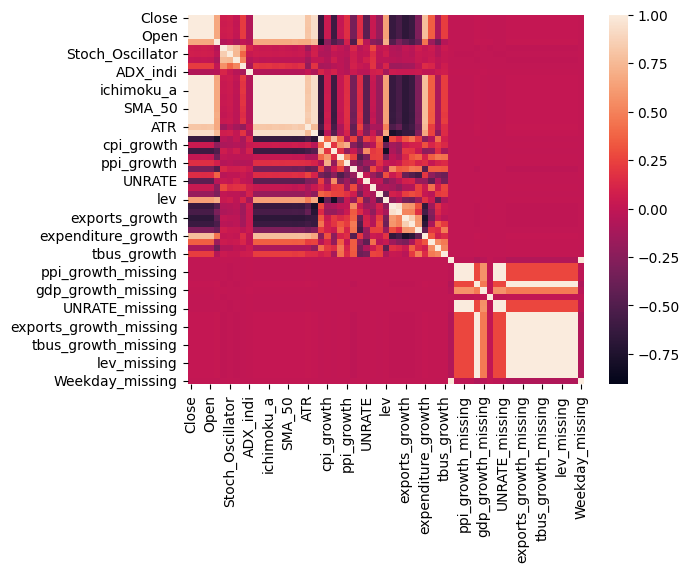

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = economic_data.corr()

sns.heatmap(corr)
plt.show()

### Random Forest Regressor Feature Importance for dataset 2


In [ ]:
X = economic_data.drop('Close', axis=1)
y = economic_data['Close']

#Random forest regressor for feature importance. Format from ChatGPT
#but modified for this particular purpose, targeting close price

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X, y)

importances = rf.feature_importances_

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance)

                       Feature    Importance
0                         High  4.653072e-01
1                          Low  4.920313e-01
2                         Open  1.961585e-02
3                       Volume  1.898124e-06
4                          RSI  2.767751e-06
5             Stoch_Oscillator  5.287681e-06
6                     ROC_indi  1.914989e-06
7                         MACD  1.187785e-06
8                     ADX_indi  1.580280e-06
9          ichimoku_conversion  9.097289e-03
10               ichimoku_base  1.157743e-03
11                  ichimoku_a  8.719574e-03
12                  ichimoku_b  1.002553e-03
13                      SMA_20  8.912236e-04
14                      SMA_50  6.129491e-04
15                     SMA_200  2.350589e-04
16             Bollinger_HBand  1.260759e-03
17                         ATR  1.560364e-06
18                        OBVI  3.632375e-05
19                       DGS10  3.019513e-06
20                  cpi_growth  1.217708e-06
21        